### Importando bibliotecas necessárias

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Patch

### Carregando o arquivo CSV e verificando as primeiras linhas do DataFrame

In [2]:
df = pd.read_csv('respostas_questionario.csv')
df.head()

,Carimbo de data/hora,Endereço de e-mail,"Declaração de suficiência dos esclarecimentos sobre a pesquisa:\r\nDeclaro que li as informações contidas nesse documento, fui devidamente informado(a) pelo(a) pesquisador (a) sobre os procedimentos que serão utilizados, riscos e desconfortos, benefícios, custo/reembolso dos participantes, confidencialidade da pesquisa, concordando ainda em participar da pesquisa. Foi-me garantido que posso retirar o consentimento a qualquer momento, sem qualquer penalidade ou prejuízo. Poderei consultar o pesquisador responsável (acima identificado) ou com o Comitê de Ética em Pesquisa com Seres Humanos do Campus Araguaia (CEP/ARAGUAIA), E-mail: cephumanos.cua@ufmt.br.com; Fone: (66) 3402-0744, sempre que entender necessário obter informações ou esclarecimentos sobre o projeto de pesquisa e minha participação no mesmo. Os resultados obtidos durante este estudo serão mantidos em sigilo, mas concordo que sejam divulgados em publicações científicas, desde que meus dados pessoais não sejam mencionados.","Declaro que li o Termo de Consentimento Livre e Esclarecido (TCLE) e que concordo em participar, como voluntário(a), da pesquisa descrita:","Declaro que faço parte do público alvo do estudo e contemplo todas as seguintes condições:\r\n\r\n- Assinalar ""Sim"" nas duas declarações iniciais; \r\n- Ter idade de 18 anos ou mais;\r\n- Ser discente/estudante de qualquer instituição de ensino superior na região de Barra do Garças - MT.",Qual seu gênero?,A instituição em que você estuda é pública ou particular?,De qual área da sua instituição você pertence?,A qual curso você pertence?,Em qual semestre você está?,...,Com qual frequência você utiliza sistemas baseados em IA generativa em suas atividades acadêmicas?,"Você considera a interação IA e acadêmicos positiva, negativa ou neutra? Por quê?",Quão familiar você se considera com as capacidades da IA generativa? (0 para pouco e 5 para muito),Você acredita que o uso da IA generativa pode comprometer a autenticidade do seu trabalho acadêmico?,"Na sua experiência, a IA generativa tem sido eficiente nas suas atividades acadêmicas?","Se sim, por que você considera a IA generativa eficiente em suas atividades acadêmicas?",Você acredita que a IA generativa é melhor que os métodos tradicionais ?,"Se sim, selecione os motivos que justificam por que a IA Generativa é considerada melhor que os métodos tradicionais","No geral, como você avalia sua experiência ao utilizar ferramentas de IA generativa no ensino superior?",Você tem alguma sugestão ou comentário adicional sobre o uso de ferramentas de IA generativa na educação superior? (Resposta aberta)
0,30/07/2024 13:29:15,wesley.santos@sou.ufmt.br,"Sim, assim eu declaro.","Sim, aceito participar como voluntário na pesq...","Sim, assim eu declaro.",Masculino,Pública,Ciências Exatas e da Terra,Ciência da Computação,9º Semestre,...,Raramente,Positiva,0,Talvez,Sim,Auxilia em correções principalmente de textos,Não,NaN,Parcialmente Satisfeito,NaN
1,30/07/2024 13:34:26,evelynfelix515@gmail.com,"Sim, assim eu declaro.","Sim, aceito participar como voluntário na pesq...","Sim, assim eu declaro.",Feminino,Pública,"Linguística, Letras e Artes",Letras,5° Semestre,...,Mensalmente,Neutra. Pois otimiza tempo se você souber usar...,4,Talvez,Não,NaN,Não,NaN,Parcialmente Satisfeito,NaN
2,30/07/2024 13:38:37,nathalia.santos1@sou.ufmt.br,"Sim, assim eu declaro.","Sim, aceito participar como voluntário na pesq...","Sim, assim eu declaro.",Feminino,Pública,Ciências Exatas e da Terra,Engenharia Civil,7° Semestre,...,Raramente,"Neutra, ela auxilia para que os prazos sejam c...",1,Não,Não,NaN,Parcialmente,"Eficiência na Geração de Conteúdo, Variedade d...",Satisfeito,NaN
3,30/07/2024 13:49:30,amandabiomed2019@gmail.com,"Sim, assim eu declaro.","Sim, aceito participar como voluntário na pesq...","Sim, assim eu declaro.",Feminino,Pública,Ciências da Saúde,Biomedicina,4° Semestre,...,Semanalmente,Acredito que a característica da interação aca...,3,Sim,

# Análise Das Perguntas Demográficas com base nas áreas de estudo

Gênero

In [ ]:
# Dicionário para agrupar as áreas (mantendo a capitalização correta)
areas_agrupadas = {
    'Ciências Agrárias': 'Ciências Agrárias',
    'Agronomia': 'Ciências Agrárias',
    'Ciências Biológicas': 'Ciências Biológicas',
    'Ciências da Saúde': 'Ciências Biológicas',
    'Educação física': 'Ciências Biológicas',
    'Ciências Exatas e da Terra': 'Ciências Exatas e da Terra',
    'Engenharias': 'Ciências Exatas e da Terra',
    'Ciências Humanas': 'Ciências Humanas e Sociais',
    'Ciências Sociais Aplicadas': 'Ciências Humanas e Sociais',
    'Direito': 'Ciências Humanas e Sociais',
    'DIREITO': 'Ciências Humanas e Sociais',
    'Linguística, Letras e Artes': 'Ciências Humanas e Sociais'
}

# Remover espaços extras
df['De qual área da sua instituição você pertence?'] = df['De qual área da sua instituição você pertence?'].str.strip()

# Aplicar a substituição e agrupar
df['Área de Estudo Agrupada'] = df['De qual área da sua instituição você pertence?'].replace(areas_agrupadas)

# Verificar áreas não mapeadas
areas_nao_mapeadas = df[~df['De qual área da sua instituição você pertence?'].isin(areas_agrupadas.keys())]
print("Áreas não mapeadas:", areas_nao_mapeadas['De qual área da sua instituição você pertence?'].unique())

# Calcular a contagem de ocorrências de cada área de estudo agrupada
contagem_areas_agrupadas = df['Área de Estudo Agrupada'].value_counts().reset_index()

# Ajustar o nome das colunas
contagem_areas_agrupadas.columns = ['Área de Estudo Agrupada', 'Contagem']

print(contagem_areas_agrupadas)

# Porcentagem ao lado de cada área de estudo agrupada
print("\nNúmero de respostas por área de estudo agrupada e porcentagem ao lado:")
for area, contagem in zip(contagem_areas_agrupadas['Área de Estudo Agrupada'], contagem_areas_agrupadas['Contagem']):
    porcentagem = (contagem / contagem_areas_agrupadas['Contagem'].sum()) * 100
    print(f"{area}: {contagem} ({porcentagem:.1f}%)")



Áreas não mapeadas: []
      Área de Estudo Agrupada  Contagem
0  Ciências Humanas e Sociais        49
1  Ciências Exatas e da Terra        28
2         Ciências Biológicas        24
3           Ciências Agrárias        22

Número de respostas por área de estudo agrupada e porcentagem ao lado:
Ciências Humanas e Sociais: 49 (39.8%)
Ciências Exatas e da Terra: 28 (22.8%)
Ciências Biológicas: 24 (19.5%)
Ciências Agrárias: 22 (17.9%)


      Área de Estudo Agrupada   Qual seu gênero?  Contagem
0           Ciências Agrárias           Feminino        10
1           Ciências Agrárias          Masculino        12
2         Ciências Biológicas           Feminino        17
3         Ciências Biológicas          Masculino         6
4         Ciências Biológicas  Prefiro não dizer         1
5  Ciências Exatas e da Terra           Feminino         8
6  Ciências Exatas e da Terra          Masculino        20
7  Ciências Humanas e Sociais           Feminino        41
8  Ciências Humanas e Sociais          Masculino         6
9  Ciências Humanas e Sociais  Prefiro não dizer         2
      Área de Estudo Agrupada   Qual seu gênero?  Contagem  Percentual
0           Ciências Agrárias           Feminino        10   45.454545
1           Ciências Agrárias          Masculino        12   54.545455
2         Ciências Biológicas           Feminino        17   70.833333
3         Ciências Biológicas          Masculino         6   25.000

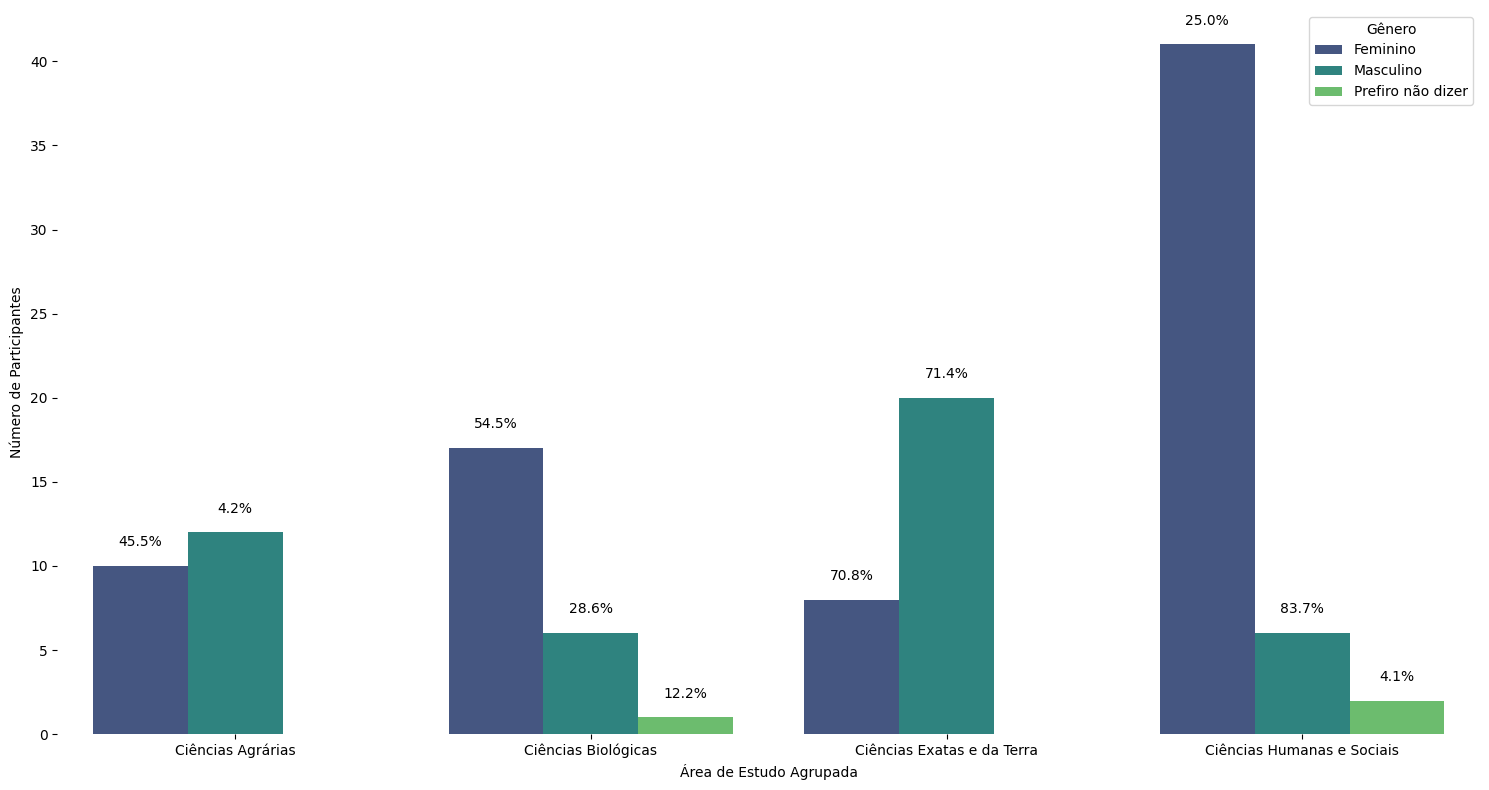

In [14]:
# Agrupar os dados por Área de Estudo Agrupada e Qual seu gênero?, calculando a contagem

# groupby é uma função do pandas que permite agrupar os dados por uma ou mais colunas
# e aplicar uma função de agregação, como contar o número de ocorrências em cada grupo.

# Aqui, estamos agrupando os dados por 'Área de Estudo Agrupada' e 'Qual seu gênero?',
# e contando o número de ocorrências em cada grupo.
# O resultado é um DataFrame com três colunas: 'Área de Estudo Agrupada', 'Qual seu gênero?' e 'Contagem'.
# O método size() conta o número de ocorrências em cada grupo e reset_index() transforma o resultado em um DataFrame.

df_grouped = df.groupby(['Área de Estudo Agrupada', 'Qual seu gênero?']).size().reset_index(name='Contagem')
print(df_grouped)

# Calcular a porcentagem de cada gênero dentro de cada área de estudo
# O método transform('sum') calcula a soma total de 'Contagem' para cada grupo de 'Área de Estudo Agrupada'
# e retorna uma série com o mesmo índice que o DataFrame original.
total_por_area = df_grouped.groupby('Área de Estudo Agrupada')['Contagem'].transform('sum')
df_grouped['Percentual'] = (df_grouped['Contagem'] / total_por_area) * 100
print(df_grouped)

# Visualizar os dados com um gráfico de barras
plt.figure(figsize=(15, 8))
ax = sns.barplot(data=df_grouped, x='Área de Estudo Agrupada', y='Contagem', 
                 hue='Qual seu gênero?', palette='viridis')

# plt.title('Interseção entre Gênero e Área de Estudo Agrupada')
plt.xlabel('Área de Estudo Agrupada')
plt.ylabel('Número de Participantes')
plt.xticks(rotation=0)
plt.legend(title='Gênero', loc='upper right')

# Adicionar os percentuais sobre as barras utilizando zip para iterar simultaneamente
for patch, (_, row) in zip(ax.patches, df_grouped.iterrows()):
    x = patch.get_x() + patch.get_width() / 2.0
    y = patch.get_height()
    ax.text(x, y + 1, f'{row["Percentual"]:.1f}%', ha='center', va='bottom', fontsize=10, color='black')


plt.box(False)
plt.grid(False)

plt.tight_layout()
plt.show()


Discentes Por Semestre

       Área de Estudo Agrupada Em qual semestre você está?  Contagem
0            Ciências Agrárias                10° Semestre         1
1            Ciências Agrárias                 1° Semestre         2
2            Ciências Agrárias                 2° Semestre         4
3            Ciências Agrárias                 4° Semestre         7
4            Ciências Agrárias                 5° Semestre         1
5            Ciências Agrárias                 6° Semestre         4
6            Ciências Agrárias                 8° Semestre         3
7          Ciências Biológicas                10° Semestre         1
8          Ciências Biológicas                 1° Semestre         1
9          Ciências Biológicas                 2° Semestre         2
10         Ciências Biológicas                 3° Semestre         3
11         Ciências Biológicas                 4° Semestre         5
12         Ciências Biológicas                 5° Semestre         1
13         Ciências Biológicas    

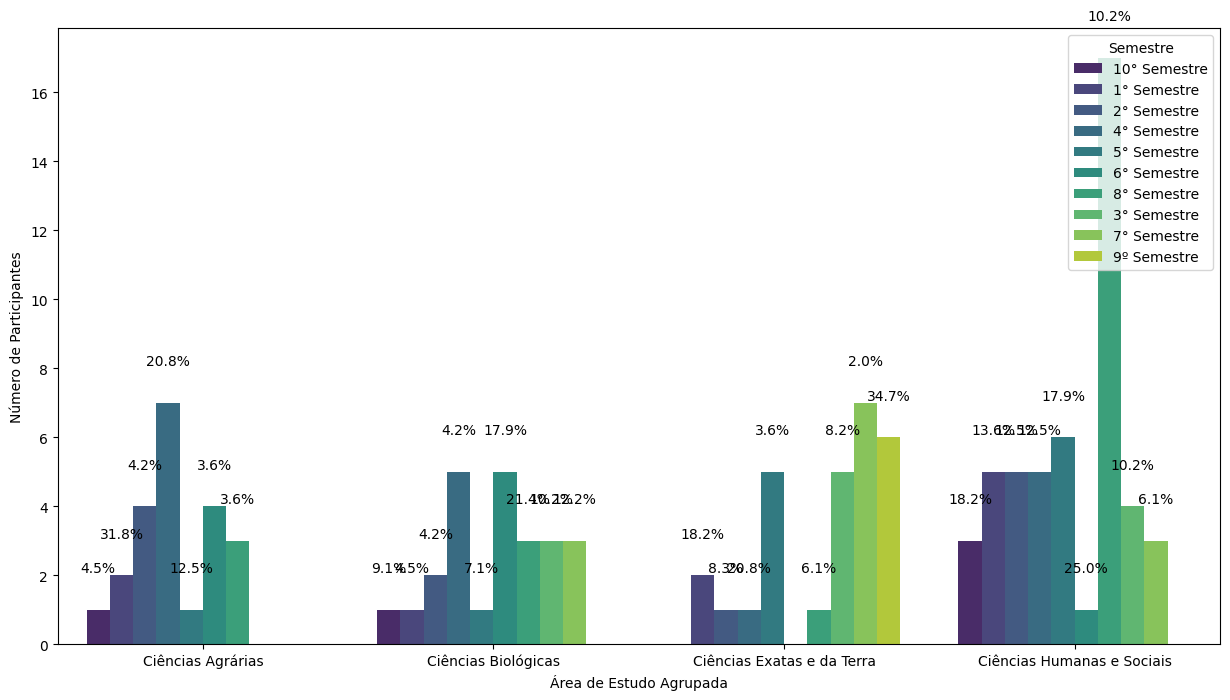

In [15]:
# Quero fazer um gráfico de pizza com a contagem de cada área de estudo agrupada em relação ao semestre que está
# cursando, mas não consegui fazer. O que posso fazer?

# Para fazer um gráfico de pizza com a contagem de cada área de estudo agrupada em relação ao semestre que está cursando,
# você pode seguir os passos abaixo:

# Ja tenho a area de estudo agrupada, agora preciso agrupar os dados por Área de Estudo Agrupada e Qual semestre você está cursando?,
# calculando a contagem

df_grouped_semestre = df.groupby(['Área de Estudo Agrupada', 'Em qual semestre você está?']).size().reset_index(name='Contagem')
print(df_grouped_semestre)

# Calcular a porcentagem de cada semestre dentro de cada área de estudo
# O método transform('sum') calcula a soma total de 'Contagem' para cada grupo de 'Área de Estudo Agrupada'
# e retorna uma série com o mesmo índice que o DataFrame original.

total_por_area_semestre = df_grouped_semestre.groupby('Área de Estudo Agrupada')['Contagem'].transform('sum')
df_grouped_semestre['Percentual'] = (df_grouped_semestre['Contagem'] / total_por_area_semestre) * 100
print(df_grouped_semestre)

# Visualizar os dados com um gráfico de pizza
plt.figure(figsize=(15, 8))
ax = sns.barplot(data=df_grouped_semestre, x='Área de Estudo Agrupada', y='Contagem', 
                 hue='Em qual semestre você está?', palette='viridis')

# plt.title('Interseção entre Semestre e Área de Estudo Agrupada')
plt.xlabel('Área de Estudo Agrupada')
plt.ylabel('Número de Participantes')
plt.xticks(rotation=0)
plt.legend(title='Semestre', loc='upper right')

# Adicionar os percentuais sobre as barras utilizando zip para iterar simultaneamente
for patch, (_, row) in zip(ax.patches, df_grouped_semestre.iterrows()):
    x = patch.get_x() + patch.get_width() / 2.0
    y = patch.get_height()
    ax.text(x, y + 1, f'{row["Percentual"]:.1f}%', ha='center', va='bottom', fontsize=10, color='black')